In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Zadanie 1

Kolory w astronomii - Wskaźniki barwy

1.1 

Wykonać unormowany wykres funkcji Plancka dla gwiazdy gorącej 12 500 K oraz chłodniejszej 5 000 K. Na wykresie zaznaczyć wartości wskaźników (U: 3520.30 Å, B = 4384.51 Å, V = 5479.85 Å, R = 6846.67 Å) oraz pasma filtrów (szerokości filtrów) U, B, V, R:

U: 3010–4100 Å 
B: 3709–5550 Å
V: 4698–7204 Å
R: 5233–9400 Å     według Johnson UBVR.

/tmp/ipykernel_6871/1799797770.py:9: RuntimeWarning: overflow encountered in exp
  intensity = a / (wavelength**5 * (np.exp(b) - 1.0))


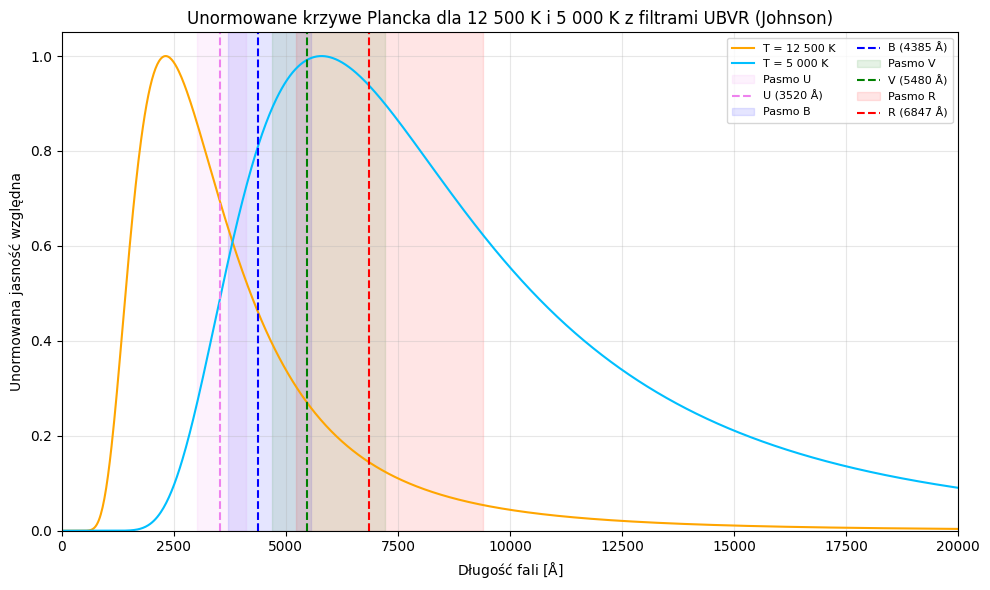

In [2]:
# Stałe fizyczne
h = 6.62607015e-34  #  Planck [J s]
c = 2.99792458e8    # prędkość światła [m/s]
k = 1.380649e-23     # Boltzmann [J/K]

def planck(wavelength, T):
    a = 2.0 * h * c**2
    b = h * c / (wavelength * k * T)
    intensity = a / (wavelength**5 * (np.exp(b) - 1.0))
    return intensity

lambda_min = 10e-10  
lambda_max = 20000e-10 
wavelengths = np.linspace(lambda_min, lambda_max, 1000)

T_hot = 12500
T_cool = 5000

B_hot = planck(wavelengths, T_hot)
B_cool = planck(wavelengths, T_cool)

B_hot /= B_hot.max()
B_cool /= B_cool.max()

filters = {
    'U': {'center': 3520.30e-10, 'range': (3010e-10, 4100e-10), 'color': 'violet'},
    'B': {'center': 4384.51e-10, 'range': (3709e-10, 5550e-10), 'color': 'blue'},
    'V': {'center': 5479.85e-10, 'range': (4698e-10, 7204e-10), 'color': 'green'},
    'R': {'center': 6846.67e-10, 'range': (5233e-10, 9400e-10), 'color': 'red'},
}

plt.figure(figsize=(10,6))
plt.plot(wavelengths*1e10, B_hot, label='T = 12 500 K', color='orange')
plt.plot(wavelengths*1e10, B_cool, label='T = 5 000 K', color='deepskyblue')

for name, f in filters.items():
    plt.axvspan(f['range'][0]*1e10, f['range'][1]*1e10, color=f['color'], alpha=0.1, label=f'Pasmo {name}')
    plt.axvline(f['center']*1e10, color=f['color'], linestyle='--', label=f'{name} ({f["center"]*1e10:.0f} Å)')

plt.xlabel(r'Długość fali [$\rm \AA$]')
plt.ylabel('Unormowana jasność względna')
plt.title('Unormowane krzywe Plancka dla 12 500 K i 5 000 K z filtrami UBVR (Johnson)')
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.xlim(0, 20000)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Obliczyć wartości wskaźnika B-V dla gwiazdy gorącej i chłodnej: 

b) obliczyć według wzoru (z funkcji Planck)

In [3]:
B_V_hot = -2.5*np.log10(planck(4385e-10, T_hot) / planck(5480e-10, T_hot))
B_V_cold = -2.5*np.log10(planck(4385e-10, T_cool) / planck(5480e-10, T_cool))

print(B_V_hot)
print(B_V_cold)
print("Dla gorącej kolor jest ujemny, a dla chłodnej - dodatni")

-0.5805514325666852
0.21771259488109634
Dla gorącej kolor jest ujemny, a dla chłodnej - dodatni


a) odczytać z wykresu i do wzory

# TBD

Wynik końcowy

Wykres: dwie krzywe Plancka z zaznaczonymi filtrami i ich szerokościami. 
Dla której gwiazdy wskaźnik barwy ma wartość pozytywną, a dla której negatywną?  
Podać wartości B–V z punktów a) i b).

---------------------------------------------------------------------------------------

1.2 Obliczyć wskaźniki barwy B–V dla 10 różnych temperatur:

40 000 K, 30 000 K, 20 000 K, 17 500 K, 15 000 K, 12 500 K, 10 000 K,  7 500 K
5 000 K, 2 500 K

w tym dla Wegi (T_Wegi = 9 790 K) i następnie wykreślić zależność temperatury od B-V. 

Wega jest używana jaka gwiazda referencyjna w systemie magnitudo, jest punktem Zero do skali. U = B = V = R = I = 0


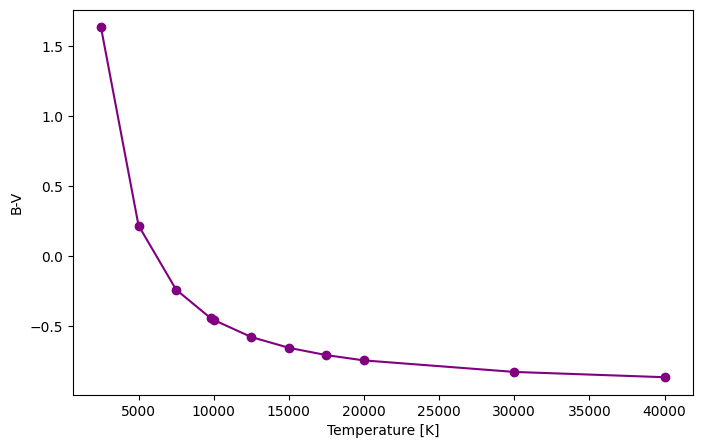

In [4]:
def B_V(T):
    return -2.5*np.log10(planck(4385e-10, T) / planck(5480e-10, T))

T = np.array([40000, 30000, 20000, 17500, 15000, 12500, 10000, 9790, 7500, 5000, 2500])
B_V_values = B_V(T)

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(T, B_V_values, marker='o', color='purple')
ax.set_ylabel('B-V')
ax.set_xlabel('Temperature [K]')
plt.show()

Taking into the Vega, as reference star with U = B = V = R = I = 0, we can calculate the B-V index for the other stars:

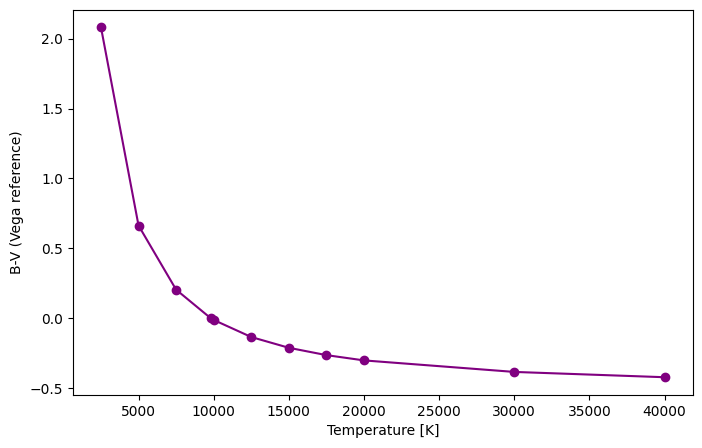

In [5]:
def B_V_Vega(T):
    return -2.5*np.log10(planck(4385e-10, T) * planck(5480e-10, 9790) / planck(5480e-10, T) / planck(4385e-10, 9790))

T = np.array([40000, 30000, 20000, 17500, 15000, 12500, 10000, 9790, 7500, 5000, 2500])
B_V_values = B_V_Vega(T)

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(T, B_V_values, marker='o', color='purple')
ax.set_ylabel('B-V (Vega reference)')
ax.set_xlabel('Temperature [K]')
plt.show()

-------------------------------------------------------------------------------------------

1.3

Sprawdzić wskaźniki barwy B-V oraz temperaturę dla wybranych gwiazd z danymi z obserwacji (nanieść na wykres z punktu 1.2), dane znajdują się w pliku: 

/ SZUFLADA / MP / BiEG / B-V / B-V-dane_obserwacje.dat

Pytanie: Dlaczego jest różnica pomiędzy wartościami obliczonymi a z obserwacji? 

Z wykresu odczytać wartości temperatur dla gwiazd: Spica, Rigel, Słońce (B-V = 0.64) i Antares (wartości wskaźników B-V z literatury baza Simbad)  i porównać z Teff dostępnymi w literaturze. 

Zaznaczyć gwiazdy na wykresie.

In [6]:
import pandas as pd
path_to_data = "/media/olehryz/Elements/progs/univ_codes/2025_2026/semester_02/inner_stars/data/B-V-dane_obserwacje.dat"
data = pd.read_csv(path_to_data, sep='\s+', comment='#', header=0)

data = data[data['B-V'] != '...']
data['B-V'] = data['B-V'].astype(float)

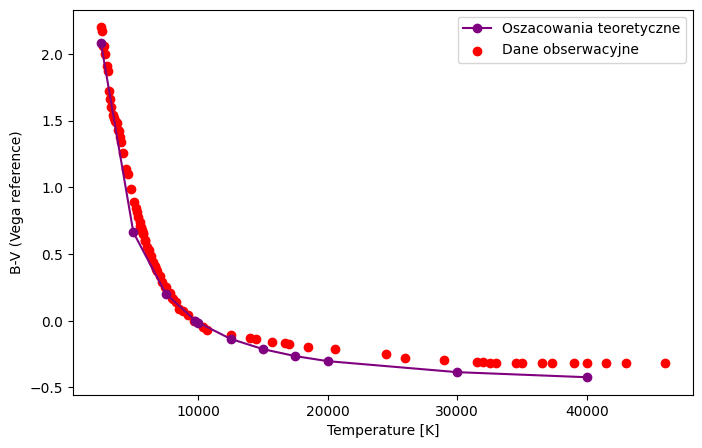

In [7]:
def B_V_Vega(T):
    return -2.5*np.log10(planck(4385e-10, T) * planck(5480e-10, 9790) / planck(5480e-10, T) / planck(4385e-10, 9790))

T = np.array([40000, 30000, 20000, 17500, 15000, 12500, 10000, 9790, 7500, 5000, 2500])
B_V_values = B_V_Vega(T)

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(T, B_V_values, marker='o', color='purple', label='Oszacowania teoretyczne')
ax.scatter(data['Teff'], data['B-V'], color='red', label='Dane obserwacyjne')
ax.set_ylabel('B-V (Vega reference)')
ax.set_xlabel('Temperature [K]')
ax.legend()
plt.show()

In [8]:
# Z Simbad:
            # TeffSimbad TeffWykres B-VLiteratura
# Spica       24683      14000   -0.23
# Rigel       12622      10000   -0.03
# Sun         5778       5000   0.64 
# Antares     3200       3000   1.84

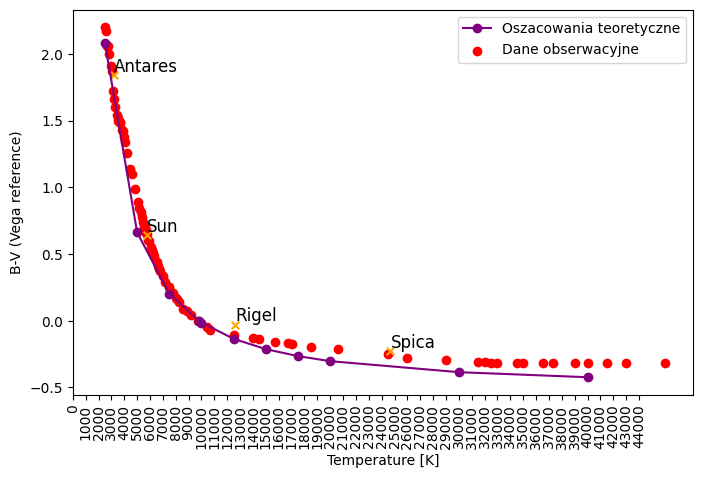

In [9]:
def B_V_Vega(T):
    return -2.5*np.log10(planck(4385e-10, T) * planck(5480e-10, 9790) / planck(5480e-10, T) / planck(4385e-10, 9790))

T = np.array([40000, 30000, 20000, 17500, 15000, 12500, 10000, 9790, 7500, 5000, 2500])
B_V_values = B_V_Vega(T)

temperatures = [24683, 12622, 5778, 3200]
names = ['Spica', 'Rigel', 'Sun', 'Antares']
B_V_obs = [-0.23, -0.03, 0.64, 1.84]

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(T, B_V_values, marker='o', color='purple', label='Oszacowania teoretyczne')
ax.scatter(data['Teff'], data['B-V'], color='red', label='Dane obserwacyjne')
ax.scatter(temperatures, B_V_obs, color='orange', s=30, marker='x')

for i in range(len(temperatures)):
    ax.text(temperatures[i], B_V_obs[i], names[i], fontsize=12, ha='left', va='bottom')
ax.set_ylabel('B-V (Vega reference)')

ax.tick_params(axis='x', labelrotation=90)
ax.set_xticks(np.arange(0, 45000, 1000))
ax.set_xlabel('Temperature [K]')
ax.legend()
plt.show()

Wynik końcowy 1.2 i 1.3

- Wykres B-V vs Teff (policzone wartości dla 10 gwiazd + Wega, wartości z obs z pliku zaznaczone gwiazdy z punktu 1.3)
- Tabelka tak jak na tablicy → gwiazdy Teff_literatura, Teff_wykres, B-V_literatura
- Odpowiedzieć na pytanie:
    Różnica wynika z dwóch powodów: gwiazdy w rzeczywistości również posiadają serie linii absorpcji, np. Balmer break + fakt, że dla obliczenia kolorów korzystaliśmy z centralnej długości fali, a nie całego pasma filtru.

--------------------------------------------------------------------------------------------

1.4 

Wykonać wykres dwuwskaźnikowy (U–B vs B–V) dla gwiazd klasy jasności V i dla nadolbrzymów Ia. 

Na wykresie trzeba umieścić:
wartości z pliku,
obliczone dla: T = 40 000 K, 20 000 K, 10 000 K, 5 000 K i 3 000 / 2 500 K  (punkty połączyć linią). 

Wykres: os x: B-V, os y: U-B [wartości od dodatnich do ujemnych].
 
Dane do wykresu: / SZUFLADA / MP / BiEG / B-V / Dane_B-V_Typ_Widmowy.dat

Pytanie: Dlaczego jest różnica pomiędzy wartościami dla klasy V i I oraz punktami z funkcji Plancka? 

**Bo funkcja Plancka nie uwzględnia poprawki dla Vegi, która jest używana jako punkt odniesienia dla kolorów + Planck nie jest idealną reprezentacją rozkładu energii gwiazdy, który omija linie absorpcyjne, np.**

Tablica: Obliczenie stałych CU-B i CV-B do uwzględnienia poprawki Wegi.

In [10]:
import pandas as pd
path_to_data = "/media/olehryz/Elements/progs/univ_codes/2025_2026/semester_02/inner_stars/data/Dane_B-V_Typ_Widmowy.dat"
data = pd.read_csv(path_to_data, sep='\s+', comment='#', header=0)

data

,Type,B-V_V,B-V_Ia,U-B_V,U-B_Ia
0,O5,-0.33,-0.31,-1.19,-1.17
1,6,-0.33,-0.31,-1.17,-1.16
2,7,-0.32,-0.31,-1.15,-1.14
3,8,-0.32,-0.29,-1.14,-1.13
4,9,-0.31,-0.27,-1.12,-1.13
5,B0,-0.30,-0.23,-1.08,-1.06
6,1,-0.26,-0.19,-0.95,-1.00
7,2,-0.24,-0.17,-0.84,-0.93
8,3,-0.20,-0.13,-0.71,-0.83
9,5,-0.17,-0.10,-0.58,-0.72


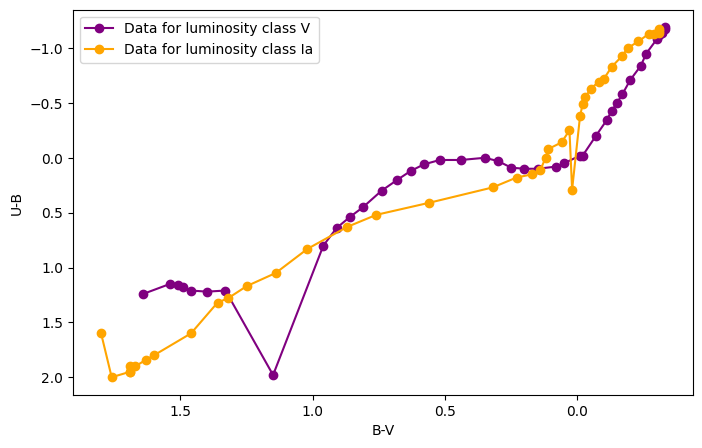

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(data['B-V_V'], data['U-B_V'], marker='o', color='purple', label='Data for luminosity class V')
ax.plot(data['B-V_Ia'], data['U-B_Ia'], marker='o', color='orange', label='Data for luminosity class Ia')
ax.set_xlabel('B-V')
ax.set_ylabel('U-B')
ax.legend()
ax.xaxis.set_inverted(True)
ax.yaxis.set_inverted(True)
plt.show()

In [23]:
width_U = 109 #nm
width_B = 184 #nm
width_V = 250 #nm

def U_B(T):
    return -2.5*np.log10(planck(3520.30e-10, T) * width_U / (planck(4384.51e-10, T) * width_B))

def B_V(T):
    return -2.5*np.log10(planck(4384.51e-10, T) * width_B / (planck(5480.00e-10, T) * width_V))

print(U_B(40000))
print(B_V(40000))

# U_B dla O5 z obserwacji wynosi -1.19 (dla V)
# B-V dla O5 z obserwacji wynosi -0.33 (dla V)

C_UB = (-1.19) - U_B(40000)
C_BV = (-0.33) - B_V(40000)

print("C_UB (nowe szerokosci)", C_UB)
print("C_BV (nowe szerokosci)", C_BV)

-0.25905533836380995
-0.5359030774783959
C_UB (nowe szerokosci) -0.93094466163619
C_BV (nowe szerokosci) 0.20590307747839592


In [24]:
width_U = 68 #nm
width_B = 98 #nm
width_V = 89 #nm

print(U_B(42000))
print(B_V(42000))

# U_B dla O5 z obserwacji wynosi -1.19 (dla V)
# B-V dla O5 z obserwacji wynosi -0.33 (dla V)

C_UB = (-1.19) - U_B(42000)
C_BV = (-0.33) - B_V(42000)

print("C_UB (stare szerokosci)", C_UB)
print("C_BV (stare szerokosci)", C_BV)

-0.4374660646957126
-0.9785392927028452
C_UB (stare szerokosci) -0.7525339353042874
C_BV (stare szerokosci) 0.6485392927028453


Generujemy wykres U-B vs B-V dla danych z pliku i obliczonych punktów z funkcji Plancka (uwzględniając poprawkę dla nowych filtrów) dla klasy V i Ia.

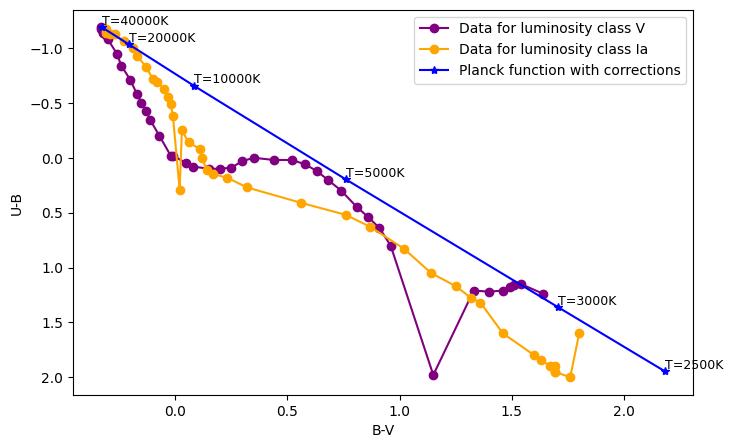

In [ ]:
T = [40000, 20000, 10000, 5000, 3000, 2500]

width_U = 109 #nm
width_B = 184 #nm
width_V = 250 #nm

def U_B_corr(T):
    return -2.5*np.log10(planck(3520.30e-10, T) * width_U / (planck(4384.51e-10, T) * width_B)) - 0.93

def B_V_corr(T):
    return -2.5*np.log10(planck(4384.51e-10, T) * width_B / (planck(5480.00e-10, T) * width_V)) + 0.21

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(data['B-V_V'], data['U-B_V'], marker='o', color='purple', label='Data for luminosity class V')
ax.plot(data['B-V_Ia'], data['U-B_Ia'], marker='o', color='orange', label='Data for luminosity class Ia')
ax.plot([B_V_corr(t) for t in T], [U_B_corr(t) for t in T], marker='*', color='blue', label='Planck function with corrections')
for t in T:
    ax.text(B_V_corr(t), U_B_corr(t), f'T={t}K', fontsize=9, ha='left', va='bottom')

ax.set_xlabel('B-V')
ax.set_ylabel('U-B')
ax.legend()
# ax.xaxis.set_inverted(True)
ax.yaxis.set_inverted(True)
plt.show()

1.5 

Porównanie krzywej teoretycznej funkcji Plancka i wskaźników barwy z wartościami otrzymanymi z widm syntetycznych 
oraz widm gwiazd standardowych

ad 1.1 

Modyfikacja zadania 1.1:

I Opcja Planck

 wykres dla Teff_1 = 9000, Teff_2 = 7000, Teff_3 = 5000 K
policzyć B-V dla 3 wartości Teff z podpunktu a)

B-V(9000) = -0.387, B-V(7000) = -0.177. B-V(5000) = +0.218 

B: 3709–5550 Å
V: 4698–7204 Å

II Opcja - widmo syntetyczne (logg = 4.0, vsini = 10, R~80 000, M/H =0.0, vmic =1, vmac=2)

wykres dla Teff_s = 9000, 7000 i 5000 K
policzyć B-V_TS1,  B-V_TS2, B-V_TS3
dla Teff = 7000 dwa widma z różnymi metalicznościami M/H = +0.5  i M/H = -0.5 
B-V_TS2_0.5, B-V_TS2_-0.5 

Uwagi:
na 3 osobnych wykresach 3 różne Teff (Planck + Planck*Synt)

Tablica z wynikami z zajęć: 20-03-2026

III Opcja - widma standardów 

z bazy: http://svocats.cab.inta-csic.es/miles/index.php 

Odpowiedniki temperaturowe dla punktu I i II

Teff_1 → HD198001	* eps Aqr	0776	A1V	0.019	3.77	9470	3.64	0.07	
Teff_2 → HD008829	* 47 Cet	0058	F0V	0.006	5.517	7163	4.15	0.06	 	
Teff_3 → BD-114126	BD-11 4126	0594	K3V	0.097 E(B-V)	10.4	5000	4.3	0.2	 

widma w katalogu na google drive, nazwy zaczynają się od miles….

Pytania: 1.5.1 Jak metaliczność wpływa na wskaźnik B-V przy tej samej temperaturze efektywnej?

Dodatkowe linki:

https://userpages.irap.omp.eu/~jleborgne/stelib_web2005/fits_files.html?utm_source=chatgpt.com 

https://www.aanda.org/articles/aa/abs/2003/17/aa3079/aa3079.html?utm_source=chatgpt.com 

http://svocats.cab.inta-csic.es/miles/index.php?action=search  

https://svo2.cab.inta-csic.es/theory/libraries/?utm_source=chatgpt.com 



https://svo2.cab.inta-csic.es/theory/fps3/index.php?id=Generic%2FJohnson.B 

# TO-DO